# Context-Aware Multimodal Knowledge Retrieval System
## Complete End-to-End RAG Pipeline for PDF / Research Paper Analysis

**What this notebook does:**
- Extracts **all content** from any PDF: text, tables, images, charts, figures, equations
- Summarizes each modality using the best LLM for that content type:
  - **Groq / Llama-3.1** → fast, free text & table summarization
  - **Gemini 1.5 Flash (Vision)** → image, chart, figure, diagram understanding
- Embeds summaries using **HuggingFace sentence-transformers**
- Stores in **ChromaDB** with a **Multi-Vector Retrieval** strategy (summary → original)
- On any query: retrieves relevant text + tables + images and generates a cited answer via **Gemini**
- Shows all **source elements** inline: rendered tables (HTML), inline images, text with page refs

---
### Architecture
```
PDF ──► Unstructured Parser ──► Text / Tables / Images
            │                        │
            │         ┌──────────────┤──────────────────────┐
            │         ▼              ▼                       ▼
            │    Groq/Llama     Groq/Llama           Gemini Vision
            │    Text Summary   Table Summary         Image Summary
            │         │              │                       │
            │         └──────────────┴───────────────────────┘
            │                        │
            │              HuggingFace Embeddings
            │                        │
            │                   ChromaDB
            │           (summaries → original docs)
            │                        │
            └──────────► MultiVectorRetriever
                                     │
                              User Question
                                     │
                           Gemini 1.5 Flash
                                     │
                    ┌────────────────┴────────────────┐
                    ▼                                 ▼
             Answer (Cited)              Sources (Text/Table/Image)
```

## Step 1 — Install & Verify Dependencies
All packages are pre-installed in the `multimodal_env` virtual environment.
Run the cell below only if you need to install/update packages.

In [ ]:
# ── Optional: Install / update packages ─────────────────────────────────────
# import subprocess, sys
# pkgs = [
#     "python-dotenv", "docling", "pymupdf", "pdfplumber", "pillow",
#     "langchain-core", "langchain-classic", "langchain-chroma",
#     "langchain-google-genai", "langchain-groq", "langchain-huggingface",
#     "google-generativeai", "sentence-transformers", "chromadb",
#     "pandas", "numpy", "diskcache", "open-clip-torch",
#     "opencv-python-headless", "matplotlib", "ipywidgets", "tqdm", "markdown",
# ]
# for pkg in pkgs:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
# print("Done.")

import importlib, sys, warnings
warnings.filterwarnings("ignore")

required = {
    "dotenv":                    "python-dotenv",
    "docling.document_converter":"docling",
    "fitz":                      "pymupdf",
    "pdfplumber":                "pdfplumber",
    "diskcache":                 "diskcache",          # persistent cache
    "open_clip":                 "open-clip-torch",    # CLIP image embeddings
    "langchain_chroma":          "langchain-chroma",
    "langchain_google_genai":    "langchain-google-genai",
    "langchain_groq":            "langchain-groq",
    "langchain_huggingface":     "langchain-huggingface",
    "langchain_classic.storage": "langchain-classic",
    "sentence_transformers":     "sentence-transformers",
    "chromadb":                  "chromadb",
    "torch":                     "torch",
    "cv2":                       "opencv-python-headless",
    "matplotlib":                "matplotlib",
    "ipywidgets":                "ipywidgets",
    "tqdm":                      "tqdm",
    "markdown":                  "markdown",
}

all_ok = True
for module, pkg in required.items():
    try:
        importlib.import_module(module)
        print(f"  ✓  {module}")
    except ImportError:
        print(f"  ✗  {module}  →  pip install {pkg}")
        all_ok = False

print()
print("All imports OK ✓" if all_ok else "⚠  Some packages missing — run the install block above.")
print(f"Python: {sys.version}")

  ✓  dotenv
  ✓  unstructured
  ✓  pdfplumber
  ✓  fitz
  ✓  langchain
  ✓  langchain_community
  ✓  langchain_google_genai
  ✓  langchain_groq
  ✓  langchain_huggingface


C:\Users\Shubhro Dev\AppData\Local\Programs\Python\Python314\Lib\importlib\__init__.py:88: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  return _bootstrap._gcd_import(name[level:], package, level)


  ✓  google.generativeai
  ✓  sentence_transformers
  ✓  chromadb
  ✓  tiktoken
  ✓  cv2
  ✓  matplotlib
  ✓  ipywidgets
  ✓  tqdm

All imports OK ✓
Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


## Step 2 — Environment Setup (API Keys)
API keys are loaded from `.env` in the project root. **Never hard-code keys in code.**

In [2]:
import os
from dotenv import load_dotenv

# Load keys from .env (project root)
load_dotenv(dotenv_path=".env", override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY", "")
GROQ_API_KEY   = os.getenv("GROQ_API_KEY",   "")
HF_TOKEN       = os.getenv("HF_TOKEN",        "")

# Propagate to environment so LangChain adapters pick them up
os.environ["GOOGLE_API_KEY"]            = GOOGLE_API_KEY
os.environ["GROQ_API_KEY"]             = GROQ_API_KEY
os.environ["HF_TOKEN"]                 = HF_TOKEN
os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

def _check(name, val):
    status = "✓ loaded" if val else "✗ MISSING — add to .env"
    print(f"  {name:<30} {status}")

print("API Key Status:")
_check("GOOGLE_API_KEY (Gemini)",  GOOGLE_API_KEY)
_check("GROQ_API_KEY",             GROQ_API_KEY)
_check("HF_TOKEN (HuggingFace)",   HF_TOKEN)

print()
if not all([GOOGLE_API_KEY, GROQ_API_KEY, HF_TOKEN]):
    print("⚠  One or more keys missing. Edit .env and re-run this cell.")
else:
    print("All API keys loaded ✓")

API Key Status:
  GOOGLE_API_KEY (Gemini)        ✓ loaded
  GROQ_API_KEY                   ✓ loaded
  HF_TOKEN (HuggingFace)         ✓ loaded

All API keys loaded ✓


In [3]:
import os
from pathlib import Path

# ── Directory constants (used throughout notebook) ──────────────────────────
CONTENT_DIR = "./content"          # PDF storage
IMAGES_DIR  = "./content/images"   # extracted image files (optional)
CHROMA_DIR  = "./chroma_db"        # persistent ChromaDB storage

for d in [CONTENT_DIR, IMAGES_DIR, CHROMA_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)
    print(f"  Ready: {d}")

print("\nDirectories set up ✓")

  Ready: ./content
  Ready: ./content/images
  Ready: ./chroma_db

Directories set up ✓


## Step 3 — Load Your PDF
Place your PDF in the `content/` folder, or use the helper below to copy it from any path.
You can also run the **widget uploader** for drag-and-drop upload inside Jupyter.

In [4]:
import shutil
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ── Option A: copy PDF from any path on your machine ───────────────────────
def load_pdf_from_path(source_path: str, rename: str = "paper.pdf") -> str:
    """
    Copy a PDF to content/ for processing.
    Usage: PDF_PATH = load_pdf_from_path(r"C:\\Users\\You\\Downloads\\paper.pdf")
    """
    src = Path(source_path)
    if not src.exists():
        raise FileNotFoundError(f"File not found: {source_path}")
    dest = Path(CONTENT_DIR) / rename
    shutil.copy2(src, dest)
    print(f"PDF copied → {dest}")
    return str(dest)

# ── Option B: drag-and-drop uploader widget ────────────────────────────────
def pdf_uploader_widget():
    """
    Interactive widget: drag a PDF onto the upload button.
    Returns a dict {'path': ...} that updates when upload is done.
    """
    uploader = widgets.FileUpload(accept=".pdf", multiple=False,
                                   description="Upload PDF",
                                   button_style="primary")
    status   = widgets.Output()
    state    = {"path": None}

    def _on_upload(change):
        with status:
            clear_output()
            for fname, fdata in uploader.value.items():
                dest = Path(CONTENT_DIR) / fname
                dest.write_bytes(fdata["content"])
                state["path"] = str(dest)
                print(f"✓ Uploaded: {dest}  ({len(fdata['content'])//1024} KB)")

    uploader.observe(_on_upload, names="value")
    display(widgets.VBox([
        widgets.HTML("<b>Upload a PDF to analyse:</b>"),
        uploader, status
    ]))
    return state   # access state["path"] after uploading

# ── Set PDF_PATH ────────────────────────────────────────────────────────────
#  → Option A (path copy):
#     PDF_PATH = load_pdf_from_path(r"C:\path\to\your.pdf")
#
#  → Option B (widget upload):
#     upload_state = pdf_uploader_widget()
#     # after uploading: PDF_PATH = upload_state["path"]
#
#  → Option C (already in content/):
PDF_PATH = "./content/Attention Is All You Need.pdf"

print(f"PDF_PATH set to: {PDF_PATH}")
if not Path(PDF_PATH).exists():
    print()
    print("⚠  File not found at that path yet.")
    print("   Use load_pdf_from_path() or the upload widget, OR copy your PDF to ./content/paper.pdf")
else:
    size_kb = Path(PDF_PATH).stat().st_size // 1024
    print(f"   File exists ✓  ({size_kb} KB)")

PDF_PATH set to: ./content/Attention Is All You Need.pdf
   File exists ✓  (2163 KB)


In [ ]:
import hashlib
import diskcache
from pathlib import Path

# ── Persistent disk cache ────────────────────────────────────────────────────
# Caches: docling extraction, Groq text/table summaries, Gemini image
# summaries, CLIP embeddings, and the retriever docstore.
# Benefit: re-running the notebook for the SAME PDF with the SAME embedding
# model skips Steps 4-8 entirely (just loads from disk in ~1 s).

CACHE_DIR = "./cache"
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

cache = diskcache.Cache(CACHE_DIR, size_limit=2 * (1024 ** 3))   # 2 GB cap

def pdf_hash(pdf_path: str) -> str:
    """
    Fast but reliable PDF fingerprint: SHA256 of the first 64 KB + file size.
    Changing even one byte of the PDF changes the hash.
    """
    h = hashlib.sha256()
    p = Path(pdf_path)
    with open(p, "rb") as f:
        h.update(f.read(65536))        # first 64 KB is enough for identity
    h.update(str(p.stat().st_size).encode())
    return h.hexdigest()[:16]

def _ck(*parts) -> str:
    """Build a namespaced cache key from arbitrary parts."""
    return ":".join(str(p) for p in parts)

# Compute once per session (changes automatically when PDF changes)
PDF_HASH = pdf_hash(PDF_PATH) if Path(PDF_PATH).exists() else "none"

used_mb = cache.volume() / (1024 ** 2)
print(f"Cache dir    : {CACHE_DIR}")
print(f"PDF hash     : {PDF_HASH}  ← changes if you swap the PDF")
print(f"Cache usage  : {used_mb:.1f} MB  (limit: 2048 MB)")
print(f"Cache entries: {len(cache)}")
print()
print("To clear the cache for this PDF (force re-extraction):")
print(f"  for k in list(cache): ")
print(f"      if '{PDF_HASH}' in str(k): del cache[k]")

## Step 4 — Extract All Multimodal Elements from PDF
Uses **Unstructured** with `hi_res` strategy (powered by a document layout model) to detect and extract:
- Text blocks (paragraphs, headers, captions)
- Tables (with HTML representation)
- Images / Figures / Charts / Diagrams (as base64)
- Equations and form elements are extracted as text where possible

> **Note:** `hi_res` strategy is thorough but slow. For a 20-page paper: ~1-3 min.

In [ ]:
import base64
import io
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling_core.types.doc import (
    PictureItem, TableItem, TextItem, DocItemLabel
)
import fitz          # PyMuPDF — high-res page image rendering
from PIL import Image as PILImage


def _run_docling_extraction(pdf_path: str) -> dict:
    """
    Core extraction logic (called only on cache miss).
    """
    if not Path(pdf_path).exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    print(f"Converting: {pdf_path}")
    print("Library: Docling (IBM) — no Tesseract required\n")

    pipeline_opts = PdfPipelineOptions()
    pipeline_opts.do_table_structure      = True
    pipeline_opts.generate_picture_images = True
    pipeline_opts.generate_table_images   = True
    pipeline_opts.images_scale            = 2.0
    pipeline_opts.do_ocr                  = False
    pipeline_opts.do_formula_enrichment   = False   # set True for math-heavy papers

    converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_opts)}
    )

    print("Running Docling converter … (may take 30-120 s for a typical paper)")
    result = converter.convert(pdf_path)
    doc    = result.document

    texts, tables, images, formulas, forms = [], [], [], [], []

    TEXT_LABELS = {
        DocItemLabel.TEXT, DocItemLabel.PARAGRAPH,
        DocItemLabel.TITLE, DocItemLabel.SECTION_HEADER,
        DocItemLabel.LIST_ITEM, DocItemLabel.CAPTION,
        DocItemLabel.FOOTNOTE, DocItemLabel.REFERENCE,
        DocItemLabel.HANDWRITTEN_TEXT,
    }
    FORM_LABELS = {
        DocItemLabel.FORM, DocItemLabel.KEY_VALUE_REGION,
        DocItemLabel.FIELD_REGION, DocItemLabel.FIELD_ITEM,
    }

    for item, _ in doc.iterate_items():
        page = item.prov[0].page_no if item.prov else None

        if isinstance(item, TableItem):
            try:
                html     = item.export_to_html()
                df       = item.export_to_dataframe()
                mdown    = item.export_to_markdown()
                caption  = item.caption_text(doc) or ""
                tables.append({
                    "html": html, "df": df, "markdown": mdown,
                    "page": page, "caption": caption, "label": "table",
                })
            except Exception as exc:
                print(f"  ⚠ Table export error (page {page}): {exc}")

        elif isinstance(item, PictureItem):
            try:
                pil_img = item.get_image(doc)
                if pil_img is not None:
                    buf = io.BytesIO()
                    pil_img.convert("RGB").save(buf, format="JPEG", quality=90)
                    b64     = base64.b64encode(buf.getvalue()).decode()
                    caption = item.caption_text(doc) or ""
                    w, h    = pil_img.size
                    images.append({
                        "b64": b64, "page": page,
                        "label": item.label.value,
                        "caption": caption, "width": w, "height": h,
                    })
            except Exception as exc:
                print(f"  ⚠ Image export error (page {page}): {exc}")

        elif item.label == DocItemLabel.FORMULA:
            text = getattr(item, "text", "") or ""
            if text.strip():
                formulas.append({"text": text, "page": page})

        elif item.label in FORM_LABELS:
            text = getattr(item, "text", "") or ""
            if text.strip():
                forms.append({"text": text, "page": page, "label": item.label.value})

        elif item.label in TEXT_LABELS:
            text = getattr(item, "text", "") or ""
            if len(text.strip()) > 20:
                texts.append({
                    "text":    text,
                    "page":    page,
                    "label":   item.label.value,
                    "heading": item.label in {
                        DocItemLabel.TITLE, DocItemLabel.SECTION_HEADER
                    },
                })

    fitz_doc  = fitz.open(pdf_path)
    meta      = fitz_doc.metadata
    toc       = fitz_doc.get_toc()
    num_pages = fitz_doc.page_count
    fitz_doc.close()

    return {
        "texts": texts, "tables": tables, "images": images,
        "formulas": formulas, "forms": forms,
        "metadata": {
            "title":  meta.get("title", Path(pdf_path).stem),
            "author": meta.get("author", ""),
            "pages":  num_pages, "toc": toc, "source": str(pdf_path),
        },
    }


# ── Cache-aware extraction ───────────────────────────────────────────────────
DOCLING_CACHE_KEY = _ck("docling_v1", PDF_HASH)

if DOCLING_CACHE_KEY in cache:
    print("═" * 60)
    print("CACHE HIT — Docling extraction loaded from disk (skipping PDF parse)")
    print("═" * 60)
    extracted = cache[DOCLING_CACHE_KEY]
else:
    print("═" * 60)
    print("CACHE MISS — Running Docling extraction (will cache result)")
    print("═" * 60)
    extracted = _run_docling_extraction(PDF_PATH)
    cache[DOCLING_CACHE_KEY] = extracted
    print("Saved to cache ✓")

texts    = extracted["texts"]
tables   = extracted["tables"]
images   = extracted["images"]
formulas = extracted["formulas"]
forms    = extracted["forms"]
pdf_meta = extracted["metadata"]

print(f"\nDocument : {pdf_meta['title']}")
print(f"Pages    : {pdf_meta['pages']}")
print(f"\nExtracted elements:")
for k in ("texts", "tables", "images", "formulas", "forms"):
    print(f"  {k:<12}: {len(extracted[k])}")

Converting: ./content/Attention Is All You Need.pdf
Library: Docling (IBM) — no Tesseract required

Running Docling converter … (may take 30-120 s for a typical paper)


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Usage of TableItem.export_to_html() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_html() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_html() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_html() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.


Extraction complete:
  texts     : 137
  tables    : 4
  images    : 6
  formulas  : 0
  forms     : 0

Document: 
Pages   : 15


In [7]:
# ── Combine formulas and forms into text pool for indexing ─────────────────
# Formulas and form fields are text-based and summarized with the text pipeline

# Add formulas to texts (they are text content, just special label)
for f in formulas:
    texts.append({
        "text":    f["text"],
        "page":    f["page"],
        "label":   "formula",
        "heading": False,
    })

# Add form elements to texts
for f in forms:
    texts.append({
        "text":    f["text"],
        "page":    f["page"],
        "label":   f["label"],
        "heading": False,
    })

print("Element summary (after merging formulas + forms into texts):")
print(f"  Text chunks (incl. formulas/forms) : {len(texts)}")
print(f"  Tables                              : {len(tables)}")
print(f"  Images / Figures / Charts           : {len(images)}")
print(f"  Formulas (separately)               : {len(formulas)}")
print(f"  Form elements (separately)          : {len(forms)}")

Element summary (after merging formulas + forms into texts):
  Text chunks (incl. formulas/forms) : 137
  Tables                              : 4
  Images / Figures / Charts           : 6
  Formulas (separately)               : 0
  Form elements (separately)          : 0


## Step 5 — Inspect Extracted Elements
Preview each modality to confirm extraction quality before summarization.

In [8]:
import base64
from IPython.display import display, HTML, Markdown

# ── Label → badge colour mapping ────────────────────────────────────────────
LABEL_COLORS = {
    "text":             "#007acc",
    "paragraph":        "#007acc",
    "title":            "#b00020",
    "section_header":   "#d84315",
    "table":            "#2e7d32",
    "picture":          "#6a1b9a",
    "chart":            "#ad1457",
    "formula":          "#00695c",
    "form":             "#4527a0",
    "key_value_region": "#283593",
    "list_item":        "#1565c0",
    "caption":          "#558b2f",
}

def _badge(label: str) -> str:
    color = LABEL_COLORS.get(label, "#555")
    return (f"<span style='background:{color}; color:white; font-size:11px;"
            f" padding:2px 7px; border-radius:10px; margin-right:6px;'>{label}</span>")

# ────────────────────────────────────────────────────────────────────────────

def display_image_b64(b64_str: str, caption: str = "", label: str = "",
                      page: int = None, max_width: int = 700):
    """Render a base64-encoded image inline."""
    badge    = _badge(label) if label else ""
    page_str = f"Page {page}" if page else ""
    display(HTML(f"""
    <div style="margin:12px 0; text-align:center;">
      <div style="margin-bottom:4px; text-align:left;">{badge}<b>{page_str}</b>
        {'  |  ' + caption if caption else ''}
      </div>
      <img src="data:image/jpeg;base64,{b64_str}"
           style="max-width:{max_width}px; border:1px solid #ccc;
                  border-radius:6px; box-shadow:0 2px 6px rgba(0,0,0,.15);"/>
    </div>
    """))


def display_table(table_dict: dict, index: int = 0):
    """Render a table dict (from docling) as an HTML table."""
    page    = table_dict.get("page", "?")
    html    = table_dict.get("html", "")
    caption = table_dict.get("caption", "")
    if not html:
        md = table_dict.get("markdown", "")
        html = f"<pre>{md[:800]}</pre>" if md else "<pre>(empty table)</pre>"
    display(HTML(f"""
    <details open>
      <summary style="font-weight:bold; cursor:pointer;">
        {_badge('table')} Table {index+1} &nbsp;|&nbsp; Page {page}
        {'  —  ' + caption if caption else ''}
      </summary>
      <div style="overflow-x:auto; margin:8px 0; padding:4px; border-left:4px solid #2e7d32;">
        {html}
      </div>
    </details>
    """))


def display_text_chunk(text_dict: dict, index: int = 0, max_chars: int = 600):
    """Render a text dict (from docling) as a styled card."""
    page    = text_dict.get("page", "?")
    label   = text_dict.get("label", "text")
    text    = text_dict.get("text", "")
    preview = text[:max_chars].replace("<", "&lt;").replace(">", "&gt;")
    if len(text) > max_chars:
        preview += " …"
    display(HTML(f"""
    <details>
      <summary style="font-weight:bold; cursor:pointer;">
        {_badge(label)} Chunk {index+1} &nbsp;|&nbsp; Page {page}
      </summary>
      <pre style="background:#f7f7f7; padding:10px; border-left:3px solid #007acc;
                  white-space:pre-wrap; font-size:13px; margin-top:4px;">{preview}</pre>
    </details>
    """))


print("Display helpers defined ✓")

Display helpers defined ✓


Showing up to 6 of 6 extracted images/figures:




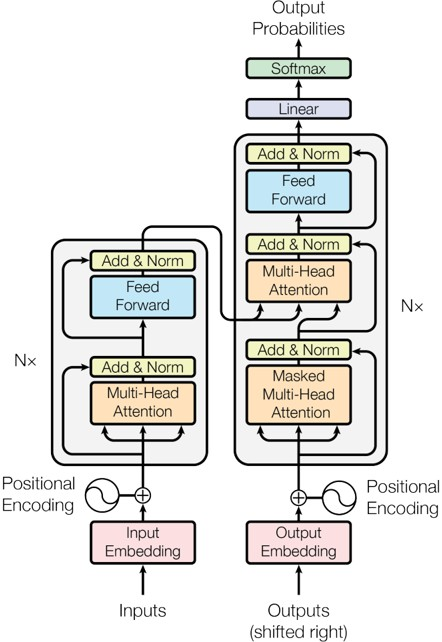


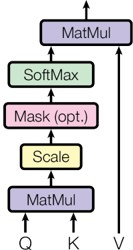


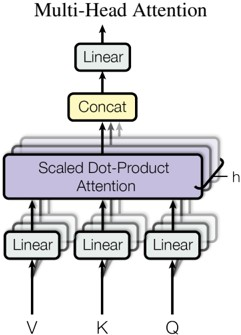


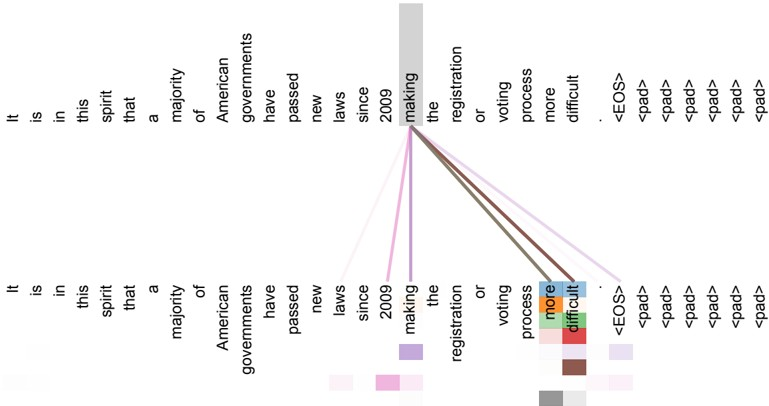


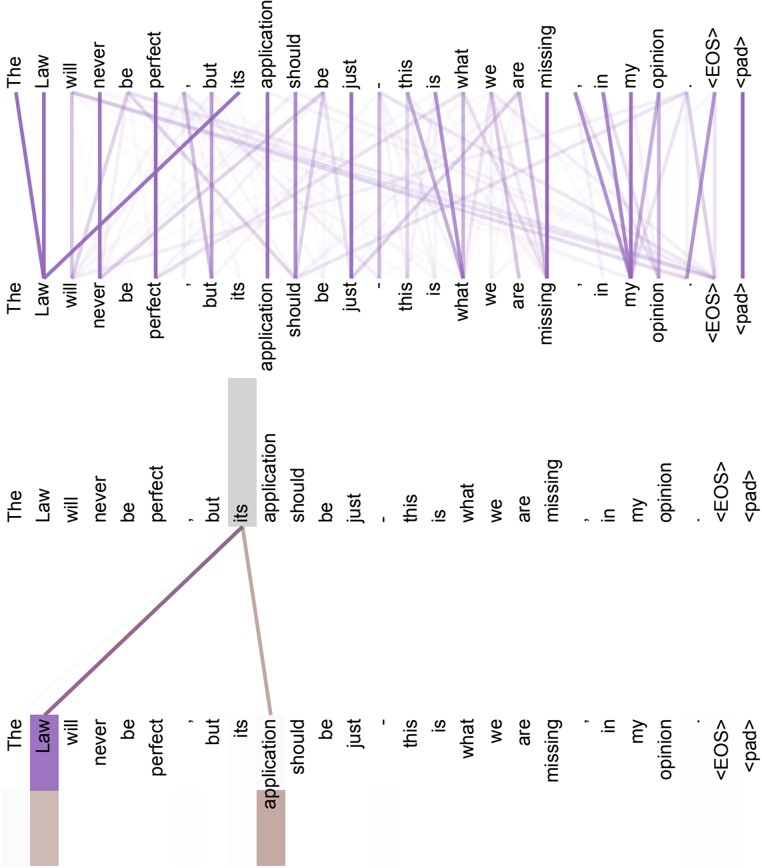


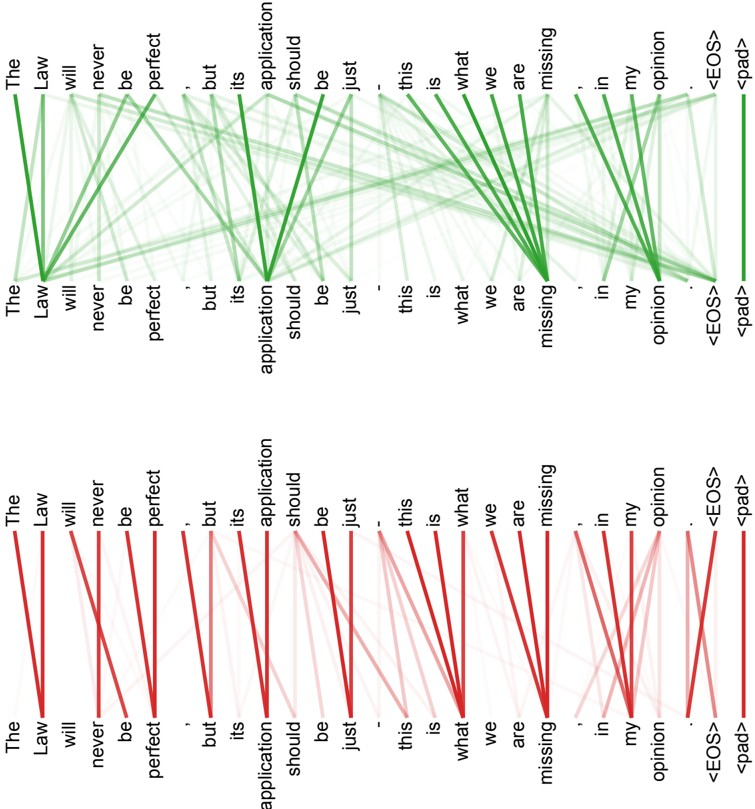

In [9]:
MAX_PREVIEW = 6
print(f"Showing up to {MAX_PREVIEW} of {len(images)} extracted images/figures:\n")
if images:
    for i, img in enumerate(images[:MAX_PREVIEW]):
        display_image_b64(
            img["b64"],
            caption=img.get("caption", ""),
            label=img.get("label", "picture"),
            page=img.get("page"),
        )
else:
    print("No images found in this document.")

In [10]:
print(f"Showing up to 4 of {len(tables)} extracted tables:\n")
if tables:
    for i, t in enumerate(tables[:4]):
        display_table(t, i)
else:
    print("No tables found in this document.")

Showing up to 4 of 4 extracted tables:



In [11]:
print(f"Showing up to 4 of {len(texts)} text chunks:\n")
for i, t in enumerate(texts[:4]):
    display_text_chunk(t, i)

Showing up to 4 of 137 text chunks:



## Step 6 — Summarize Text & Tables with Groq (Llama-3.1)
- Fast, free, open-source LLM inference
- Text chunks → concise paragraph summaries
- Tables → analytical descriptions (headers, values, trends, conclusions)

These summaries are what get embedded and searched — the **original** elements are stored separately and retrieved on match.

In [12]:
import warnings
warnings.filterwarnings("ignore")

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ── Groq LLM ────────────────────────────────────────────────────────────────
# Production models (verified May 2026):
#   llama-3.3-70b-versatile  — 280 tps, best quality,  131k ctx
#   llama-3.1-8b-instant     — 560 tps, fast & cheap,  131k ctx
#   openai/gpt-oss-20b       — 1000 tps, very fast,    131k ctx
#
# Change to llama-3.1-8b-instant or openai/gpt-oss-20b if you hit rate limits.

groq_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    api_key=GROQ_API_KEY,
)

# ── Text summarization prompt ────────────────────────────────────────────────
TEXT_PROMPT = ChatPromptTemplate.from_template("""
You are an expert academic research assistant. Analyse the following passage
extracted from a research paper or document.

Write a concise, information-dense summary (3-6 sentences) that captures:
- The main topic, argument, or finding
- Key facts, methods, models, metrics, or claims
- Named entities (authors, datasets, architectures, benchmarks)
- Context within the paper (e.g. intro, related work, method, experiment)

Do NOT start with "Here is a summary" or "This passage discusses". Just write the summary.

Element type: {label}
Page: {page}
Content:
{element}
""")

# ── Table summarization prompt ───────────────────────────────────────────────
TABLE_PROMPT = ChatPromptTemplate.from_template("""
You are an expert data analyst reviewing a table from a research paper.

Provide a structured, information-dense description covering:
1. What the table reports (metric, comparison, ablation study, etc.)
2. Column and row headers
3. Key numerical values, best/worst results, rankings
4. Trends, patterns, or notable observations
5. What conclusion the table supports

Do NOT start with "Here is a summary". Just write the analysis directly.

Caption (if any): {caption}
Page: {page}
Table (HTML):
{element}
""")

text_chain  = ({"element": lambda x: x["text"],  "label": lambda x: x.get("label","text"),
                "page":    lambda x: x.get("page","?")}
               | TEXT_PROMPT | groq_llm | StrOutputParser())

table_chain = ({"element": lambda x: x["html"],   "caption": lambda x: x.get("caption",""),
                "page":    lambda x: x.get("page","?")}
               | TABLE_PROMPT | groq_llm | StrOutputParser())

print("Groq summarization chains ready ✓")
print(f"  Model              : llama-3.3-70b-versatile")
print(f"  Text chunks        : {len(texts)}")
print(f"  Tables             : {len(tables)}")

Groq summarization chains ready ✓
  Model              : llama-3.3-70b-versatile
  Text chunks        : 137
  Tables             : 4


In [ ]:
from tqdm.notebook import tqdm
import time

# ── Cache key prefix (includes PDF + model so switching model forces fresh summaries)
_SUMM_PREFIX = _ck("groq_summ_v1", PDF_HASH, "llama-3.3-70b-versatile")

def _cached_invoke(chain, payload, cache_key):
    if cache_key in cache:
        return cache[cache_key], True   # (result, from_cache)
    for attempt in range(3):
        try:
            result = chain.invoke(payload)
            cache[cache_key] = result
            return result, False
        except Exception as exc:
            if attempt < 2:
                time.sleep(5 * (attempt + 1))
            else:
                return str(payload)[:300], False   # fallback: raw text

# ── Summarize text chunks ─────────────────────────────────────────────────────
print("Summarizing text chunks …  (cached chunks are instant)")
text_summaries = []
cached_count   = 0
for i, chunk in enumerate(tqdm(texts, desc="Text")):
    ck = _ck(_SUMM_PREFIX, "text", i)
    summary, from_cache = _cached_invoke(text_chain, chunk, ck)
    text_summaries.append(summary)
    if from_cache:
        cached_count += 1
    else:
        time.sleep(0.15)   # polite rate-limiting only for new API calls

print(f"  Done: {len(text_summaries)} summaries "
      f"({cached_count} from cache, {len(text_summaries)-cached_count} new)\n")

# ── Summarize tables ──────────────────────────────────────────────────────────
if tables:
    print("Summarizing tables …")
    table_summaries = []
    cached_count    = 0
    for i, tbl in enumerate(tqdm(tables, desc="Tables")):
        ck = _ck(_SUMM_PREFIX, "table", i)
        summary, from_cache = _cached_invoke(table_chain, tbl, ck)
        table_summaries.append(summary)
        if from_cache:
            cached_count += 1
        else:
            time.sleep(0.15)
    print(f"  Done: {len(table_summaries)} summaries "
          f"({cached_count} from cache, {len(table_summaries)-cached_count} new)\n")
else:
    table_summaries = []
    print("No tables to summarize.")

# ── Sanity check ──────────────────────────────────────────────────────────────
if text_summaries:
    print("── Sample text summary (chunk 0) ──────────────────────────────────")
    print(text_summaries[0][:400])
if table_summaries:
    print("\n── Sample table summary (table 0) ─────────────────────────────────")
    print(table_summaries[0][:400])

Summarizing text chunks …


Text:   0%|          | 0/137 [00:00<?, ?it/s]

  Done: 137 text summaries

Summarizing tables …


Tables:   0%|          | 0/4 [00:00<?, ?it/s]

  Done: 4 table summaries

── Sample text summary (chunk 0) ──────────────────────────────────
The passage appears to be from the introductory or licensing section of a research paper, likely published by Google. The statement grants permission to reproduce tables and figures from the paper for journalistic or scholarly purposes, provided proper attribution is given. This suggests that the paper contains original research or data that Google is willing to share with the academic community. The context implies that the paper is intended for public consumption and may contribute to ongoing 

── Sample table summary (table 0) ─────────────────────────────────
Table 1 reports the results of an ablation study comparing the computational complexity of different layer types in terms of maximum path lengths, per-layer complexity, and minimum number of sequential operations. The table has column headers for 'Layer Type', 'Max Path Length', 'Per-Layer Complexity', and 'Min Seq Ops', while the ro

## Step 7 — Summarize Images & Figures with Gemini Vision
Gemini 1.5 Flash processes each extracted image and produces detailed descriptions covering:
- Figure type (bar chart, scatter plot, diagram, equation, photo, etc.)
- All visible text labels, axis labels, legends
- Key data, trends, and takeaways
- What the figure communicates in the context of the paper

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import time

# ── Gemini Vision model ───────────────────────────────────────────────────────
gemini_vision = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0.1,
)

IMAGE_DESCRIBE_PROMPT = """This image is extracted from a research paper or academic document.
Provide a detailed, structured description covering ALL of the following:

1. **Element type**: (bar chart / line graph / scatter plot / pie chart / architecture diagram /
   network diagram / flowchart / equation / screenshot / photograph / table screenshot / other)
2. **All visible text**: axis labels, titles, legends, annotations, callouts, captions
3. **Key data / values**: specific numbers, percentages, comparisons, ranges
4. **Trends / patterns**: what the data or diagram shows directionally
5. **Main insight**: what conclusion or argument this figure supports in the paper
6. **Layout / structure**: how the visual is organized (multi-panel, color coding, arrows, etc.)

Be thorough and specific — your description will be the only textual representation of this
figure and must enable semantic search and question-answering about it."""

_IMG_SUMM_PREFIX = _ck("gemini_img_v1", PDF_HASH, "gemini-2.5-flash")

def summarize_image_gemini(img_dict: dict, img_idx: int) -> str:
    """
    Describe a single image dict {b64, page, label, caption} using Gemini Vision.
    Checks cache first; saves result to cache on new API call.
    """
    ck = _ck(_IMG_SUMM_PREFIX, img_idx)
    if ck in cache:
        return cache[ck]

    b64     = img_dict["b64"]
    caption = img_dict.get("caption", "")
    label   = img_dict.get("label", "picture")

    prompt_txt = IMAGE_DESCRIBE_PROMPT
    if caption:
        prompt_txt += f"\n\nFigure caption from paper: \"{caption}\""
    if label == "chart":
        prompt_txt += "\n\nNote: This element was identified as a CHART by the document parser."

    try:
        msg  = HumanMessage(content=[
            {"type": "text", "text": prompt_txt},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
        ])
        resp = gemini_vision.invoke([msg])
        result = resp.content
    except Exception as exc:
        result = f"[Vision description unavailable: {exc}]"

    cache[ck] = result
    return result


# ── Run image summarization (cache-aware) ────────────────────────────────────
if images:
    print(f"Summarizing {len(images)} images with Gemini 2.5 Flash Vision …")
    print("(cached images are instant)")
    image_summaries = []
    cached_count    = 0
    for i, img_dict in enumerate(images):
        ck = _ck(_IMG_SUMM_PREFIX, i)
        from_cache = ck in cache
        if from_cache:
            cached_count += 1
        else:
            print(f"  Figure {i+1}/{len(images)} (page {img_dict.get('page','?')}, "
                  f"label={img_dict.get('label','?')}) …", end="\r")
            time.sleep(0.5)

        summary = summarize_image_gemini(img_dict, i)
        image_summaries.append(summary)

    print(f"\nDone: {len(image_summaries)} summaries "
          f"({cached_count} from cache, {len(image_summaries)-cached_count} new) ✓")
    if image_summaries:
        print("\n── Sample image summary (figure 0) ────────────────────────────────")
        print(image_summaries[0][:600])
else:
    image_summaries = []
    print("No images found in this document.")

Summarizing 6 images with Gemini 2.5 Flash Vision …
  Figure 6/6 (page 15, label=picture) …
Done: 6 image summaries ✓

── Sample image summary (figure 0) ────────────────────────────────
This figure is an architecture diagram illustrating the structure of the Transformer model.

**1. Element type**: Architecture diagram / Block diagram.

**2. All visible text**:
*   **Title (from caption)**: Figure 1: The Transformer - model architecture.
*   **Top-most output**: Output Probabilities
*   **Final output layers**: Softmax, Linear
*   **Decoder stack (from top to bottom)**:
    *   Add & Norm
    *   Feed Forward
    *   Add & Norm
    *   Multi-Head Attention
    *   Add & Norm
    *   Masked Multi-Head Attention
*   **Encoder stack (from top to bottom)**:
    *   Add & Norm
    *   Feed Forward
    *   Add & Norm
    *   Multi-Head Attention
*   **Embedding layers**: Input Em


## Step 8 — Embeddings + ChromaDB Multi-Vector Retriever
**Strategy:**
- Each modality's **summary** is embedded and stored in ChromaDB (the search layer)
- The **original** element (raw text, table HTML, image base64) is stored in a docstore keyed by the same UUID
- On retrieval: ChromaDB finds the best-matching summaries → their UUIDs fetch the originals from the docstore
- The final answer generation sees the **original** content (not just summaries)

In [15]:
import warnings
warnings.filterwarnings("ignore")
from langchain_huggingface import HuggingFaceEmbeddings

# ── HuggingFace Embeddings ───────────────────────────────────────────────────
# Model options (all run on CPU, no API key needed):
#   BAAI/bge-base-en-v1.5    — 768-dim, strong semantic similarity  ← default
#   BAAI/bge-large-en-v1.5   — 1024-dim, even stronger (slower)
#   sentence-transformers/all-MiniLM-L6-v2  — 384-dim, fastest (weaker)

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},             # change to "cuda" if GPU available
    encode_kwargs={
        "normalize_embeddings": True,           # required for BGE cosine similarity
        "batch_size": 32,
    },
)

# Sanity check
sample_vec = embedding_model.embed_query("multimodal retrieval augmented generation")
print("Embedding model loaded ✓")
print(f"  Model : BAAI/bge-base-en-v1.5")
print(f"  Dim   : {len(sample_vec)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model loaded ✓
  Model : BAAI/bge-base-en-v1.5
  Dim   : 768


In [16]:
import uuid
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# langchain 1.x: use standalone integration packages
from langchain_chroma import Chroma                                 # pip install langchain-chroma
from langchain_classic.storage import InMemoryStore                # pip install langchain-classic
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.documents import Document

DOC_ID_KEY = "doc_id"    # metadata key linking summary → original

# ── ChromaDB (persistent) ────────────────────────────────────────────────────
vectorstore = Chroma(
    collection_name="multimodal_rag",
    embedding_function=embedding_model,
    persist_directory=CHROMA_DIR,          # saves to ./chroma_db automatically
)

# ── In-memory docstore for original elements ─────────────────────────────────
# Keys   : UUID strings
# Values : original elements (Unstructured chunk, HTML string, base64 image string)
docstore = InMemoryStore()

# ── MultiVectorRetriever ─────────────────────────────────────────────────────
# On .invoke(query):
#   1. Embeds the query
#   2. Finds top-k summaries in ChromaDB
#   3. Looks up their UUIDs in docstore
#   4. Returns original elements
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    id_key=DOC_ID_KEY,
    search_kwargs={"k": 6},       # retrieve top 6 most relevant chunks
)

print("ChromaDB + MultiVectorRetriever initialized ✓")
print(f"  Persist directory : {CHROMA_DIR}")
print(f"  Search k          : 6")

ChromaDB + MultiVectorRetriever initialized ✓
  Persist directory : ./chroma_db
  Search k          : 6


In [17]:
def _add_to_retriever(
    originals: list,
    summaries: list,
    retriever,
    modality: str,
    extra_meta_fn=None,
) -> list:
    """
    Index a batch of elements into ChromaDB + docstore.

    Args:
        originals    : list of original elements (dicts from docling, or b64 strings for images)
        summaries    : list of text summaries (same length)
        retriever    : MultiVectorRetriever
        modality     : "text" | "table" | "image"
        extra_meta_fn: optional callable(i, original) → dict of extra metadata

    Returns list of UUIDs assigned.
    """
    if not originals:
        return []

    ids = [str(uuid.uuid4()) for _ in originals]

    summary_docs = []
    for i, (doc_id, summary) in enumerate(zip(ids, summaries)):
        meta = {DOC_ID_KEY: doc_id, "modality": modality}
        if extra_meta_fn:
            meta.update(extra_meta_fn(i, originals[i]))
        summary_docs.append(Document(page_content=summary, metadata=meta))

    retriever.vectorstore.add_documents(summary_docs)
    retriever.docstore.mset(list(zip(ids, originals)))
    return ids


# ── Index texts ──────────────────────────────────────────────────────────────
print("Indexing text chunks …")
text_ids = _add_to_retriever(
    texts, text_summaries, retriever, modality="text",
    extra_meta_fn=lambda i, el: {
        "page":  el.get("page", -1),
        "label": el.get("label", "text"),
    },
)

# ── Index tables ─────────────────────────────────────────────────────────────
print("Indexing tables …")
table_ids = _add_to_retriever(
    tables, table_summaries, retriever, modality="table",
    extra_meta_fn=lambda i, el: {
        "page":    el.get("page", -1),
        "caption": el.get("caption", ""),
    },
)

# ── Index images ─────────────────────────────────────────────────────────────
print("Indexing images …")
image_ids = _add_to_retriever(
    images, image_summaries, retriever, modality="image",
    extra_meta_fn=lambda i, el: {
        "page":    el.get("page", -1),
        "label":   el.get("label", "picture"),
        "caption": el.get("caption", ""),
    },
)

total = len(text_ids) + len(table_ids) + len(image_ids)
print(f"\nIndexing complete ✓")
print(f"  Text chunks : {len(text_ids)}")
print(f"  Tables      : {len(table_ids)}")
print(f"  Images      : {len(image_ids)}")
print(f"  Total       : {total}")
print(f"  ChromaDB    : {vectorstore._collection.count()} vectors stored")

Indexing text chunks …
Indexing tables …
Indexing images …

Indexing complete ✓
  Text chunks : 137
  Tables      : 4
  Images      : 6
  Total       : 147
  ChromaDB    : 147 vectors stored


In [18]:
# ── Verify retrieval works ───────────────────────────────────────────────────
test_q = "What is the main topic and contribution of this paper?"
print(f"Test query: '{test_q}'\n")

raw_docs = retriever.invoke(test_q)
print(f"Retrieved {len(raw_docs)} docs:\n")

for i, doc in enumerate(raw_docs):
    if isinstance(doc, dict):
        modality = doc.get("label", "?")
        page     = doc.get("page", "?")
        if "b64" in doc:
            print(f"  [{i+1}] IMAGE   label={doc.get('label','?')}  page={page}  "
                  f"caption='{doc.get('caption','')[:60]}'")
        elif "html" in doc:
            print(f"  [{i+1}] TABLE   page={page}  "
                  f"caption='{doc.get('caption','')[:60]}'")
        else:
            print(f"  [{i+1}] {modality.upper():<12} page={page}: "
                  f"{doc.get('text','')[:100]} …")
    elif isinstance(doc, str):
        print(f"  [{i+1}] RAW STRING (len={len(doc)})")
    else:
        print(f"  [{i+1}] {type(doc).__name__}: {str(doc)[:120]}")

Test query: 'What is the main topic and contribution of this paper?'

Retrieved 6 docs:

  [1] TEXT         page=1: illia.polosukhin@gmail.com …
  [2] TEXT         page=1: Ashish Vaswani ∗ Google Brain avaswani@google.com Noam Shazeer ∗ Google Brain noam@google.com …
  [3] LIST_ITEM    page=10: Jimmy Lei Ba, Jamie Ryan Kiros, and Geoffrey E Hinton. Layer normalization. arXiv preprint arXiv:160 …
  [4] TEXT         page=3: An attention function can be described as mapping a query and a set of key-value pairs to an output, …
  [5] LIST_ITEM    page=11: Alex Graves. Generating sequences with recurrent neural networks. arXiv preprint arXiv:1308.0850 , 2 …
  [6] LIST_ITEM    page=11: Łukasz Kaiser and Ilya Sutskever. Neural GPUs learn algorithms. In International Conference on Learn …


## Step 9 — RAG Pipeline with Source Citation
The pipeline:
1. Embeds the user query
2. Retrieves top-k original elements (text + tables + images)
3. Builds a multimodal prompt (text context + images attached)
4. Sends to **Gemini 1.5 Flash** for final answer generation
5. Returns both the answer **and** all source elements used

In [19]:
from base64 import b64decode
import warnings
warnings.filterwarnings("ignore")


def classify_docs(raw_docs: list) -> dict:
    """
    Split raw retrieved docs into three modality buckets.
    Docling elements are stored as dicts; images have a 'b64' key.

    Returns:
        texts  : list of text dicts  {text, page, label, ...}
        tables : list of table dicts {html, df, page, caption, ...}
        images : list of image dicts {b64, page, label, caption, ...}
    """
    out = {"texts": [], "tables": [], "images": []}
    for doc in raw_docs:
        if isinstance(doc, dict):
            if "b64" in doc:
                out["images"].append(doc)
            elif "html" in doc or "df" in doc:
                out["tables"].append(doc)
            else:
                out["texts"].append(doc)
        elif isinstance(doc, str):
            # Legacy: bare base64 string stored as image
            try:
                b64decode(doc[:128])
                out["images"].append({"b64": doc, "page": None, "label": "picture", "caption": ""})
            except Exception:
                out["texts"].append({"text": doc, "page": None, "label": "text"})
        else:
            # Unstructured or other legacy object
            out["texts"].append(doc)
    return out


def build_rag_prompt(context: dict, question: str) -> list:
    """
    Build a HumanMessage list for Gemini.
    - Text + table content goes as context in the prompt text
    - Images are attached as vision inputs
    """
    parts = []

    for chunk in context["texts"]:
        if isinstance(chunk, dict):
            text  = chunk.get("text", "")
            page  = chunk.get("page", "?")
            label = chunk.get("label", "text")
        else:
            text  = getattr(chunk, "text", str(chunk))
            page  = getattr(getattr(chunk, "metadata", None), "page_number", "?")
            label = "text"
        if text.strip():
            parts.append(f"[{label.upper()} — page {page}]\n{text}")

    for tbl in context["tables"]:
        if isinstance(tbl, dict):
            content = tbl.get("html") or tbl.get("markdown") or tbl.get("text", "")
            page    = tbl.get("page", "?")
            caption = tbl.get("caption", "")
        else:
            content = getattr(getattr(tbl, "metadata", None), "text_as_html", getattr(tbl, "text", str(tbl)))
            page    = getattr(getattr(tbl, "metadata", None), "page_number", "?")
            caption = ""
        parts.append(f"[TABLE — page {page}]{'  Caption: '+caption if caption else ''}\n{content}")

    ctx_str = "\n\n---\n\n".join(parts) if parts else "(no text or table context retrieved)"

    system_instruction = (
        "You are an expert research assistant. Answer the question using ONLY "
        "the provided context (text passages, tables, and any attached images).\n\n"
        "RULES:\n"
        "- Always cite the page number when referencing text or tables, e.g. (page 4)\n"
        "- When referencing a figure, describe what you see in it (if image attached)\n"
        "- Quote exact numbers from tables rather than paraphrasing\n"
        "- If context is insufficient for a complete answer, say so clearly\n"
        "- Structure your answer with headers or bullet points when helpful\n"
        "- Be thorough and specific\n\n"
        f"=== CONTEXT ===\n{ctx_str}\n\n"
        f"=== QUESTION ===\n{question}"
    )

    content = [{"type": "text", "text": system_instruction}]

    for img in context["images"]:
        b64 = img["b64"] if isinstance(img, dict) else img
        content.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{b64}"},
        })

    return [HumanMessage(content=content)]


# ── Gemini for final answer generation ──────────────────────────────────────
gemini_answer = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0.1,
)

print("RAG pipeline helpers defined ✓")
print("  Answer model: gemini-2.5-flash")

RAG pipeline helpers defined ✓
  Answer model: gemini-2.5-flash


In [20]:
from IPython.display import display, HTML, Markdown
import textwrap


def display_sources(context: dict, max_images: int = 4) -> None:
    """Render all retrieved sources in the notebook for citation transparency."""

    display(HTML("<hr><h3>📌 Retrieved Sources</h3>"))

    if context["texts"]:
        display(HTML(f"<b>Text passages ({len(context['texts'])})</b>"))
        for i, t in enumerate(context["texts"]):
            if isinstance(t, dict):
                page  = t.get("page", "?")
                label = t.get("label", "text").upper()
                text  = t.get("text", "")
            else:
                page  = getattr(getattr(t, "metadata", None), "page_number", "?")
                label = "TEXT"
                text  = getattr(t, "text", str(t))
            snippet = textwrap.shorten(text, width=300, placeholder=" …")
            display(HTML(
                f'<div style="border:1px solid #ddd;padding:8px;margin:4px 0;'
                f'border-radius:4px;background:#f9f9ff">'
                f'<small><b>{label}</b> · page {page}</small><br>'
                f'<span style="font-size:0.92em">{snippet}</span></div>'
            ))

    if context["tables"]:
        display(HTML(f"<b>Tables ({len(context['tables'])})</b>"))
        for i, tbl in enumerate(context["tables"]):
            display_table(tbl, i)

    if context["images"]:
        display(HTML(f"<b>Figures / Charts ({min(len(context['images']), max_images)} "
                     f"of {len(context['images'])})</b>"))
        for i, img in enumerate(context["images"][:max_images]):
            if isinstance(img, dict):
                b64     = img.get("b64", "")
                page    = img.get("page", "?")
                label   = img.get("label", "picture")
                caption = img.get("caption", "")
            else:
                b64 = img
                page = label = caption = "?"
            display_image_b64(b64, page=page, label=label, caption=caption)


def query_paper(question: str, k: int = 6, show_sources: bool = True) -> str:
    """
    Full RAG pipeline:
    1. Retrieve k relevant docs (multi-modal)
    2. Classify into texts / tables / images
    3. Build multimodal prompt (text + table context, inline images)
    4. Ask Gemini 2.5 Flash for an answer
    5. Optionally display all source citations
    """
    print(f"\n{'='*70}")
    print(f"QUESTION: {question}")
    print(f"{'='*70}\n")

    # -- Retrieve
    retriever.search_kwargs = {"k": k}
    raw_docs = retriever.invoke(question)

    # -- Classify
    context = classify_docs(raw_docs)
    print(f"Retrieved: {len(context['texts'])} text  |  "
          f"{len(context['tables'])} table  |  "
          f"{len(context['images'])} image\n")

    # -- Show sources first (if requested)
    if show_sources:
        display_sources(context)
        display(HTML("<hr>"))

    # -- Build prompt + answer
    messages = build_rag_prompt(context, question)
    response = gemini_answer.invoke(messages)
    answer   = response.content if hasattr(response, "content") else str(response)

    display(HTML("<h3>💬 Answer</h3>"))
    display(Markdown(answer))

    return answer


print("query_paper() ready ✓")
print("Usage: answer = query_paper('your question here', k=6)")

query_paper() ready ✓
Usage: answer = query_paper('your question here', k=6)


## Step 10 — Ask Questions About Your Document
Use `query_paper("your question")` for any question.
The answer will be followed by **all source elements** (text, tables, images) that contributed.

In [21]:
# ── Example question 1: Overview ────────────────────────────────────────────
result = query_paper("What is the main topic and key contribution of this paper?")


QUESTION: What is the main topic and key contribution of this paper?

Retrieved: 6 text  |  0 table  |  0 image



The provided context is insufficient to determine the main topic and key contribution of this paper.

The text describes an attention function as mapping a query and a set of key-value pairs to an output, where the output is computed as a weighted sum (page 3). However, it does not state that this description is the main topic or a key contribution of the paper itself. No abstract, introduction, or summary of the paper's purpose or findings is included in the context.

In [22]:
# ── Example question 2: Tables / numbers ────────────────────────────────────
result2 = query_paper(
    "What experimental results or performance numbers are reported? "
    "Include any benchmark comparisons from tables."
)


QUESTION: What experimental results or performance numbers are reported? Include any benchmark comparisons from tables.

Retrieved: 6 text  |  0 table  |  0 image



The provided context mentions that experimental results and performance numbers are summarized in Table 2, but Table 2 itself is not included. Therefore, the context is insufficient to provide a complete answer regarding the reported experimental results or performance numbers.

However, the context does provide the following information related to performance estimation:

*   **GPU Sustained Single-Precision Floating-Point Capacity Estimates**
    The following values were used to estimate the sustained single-precision floating-point capacity of each GPU (page 8, footnote 5):
    *   K80: 2.8 TFLOPS
    *   K40: 3.7 TFLOPS
    *   M40: 6.0 TFLOPS
    *   P100: 9.5 TFLOPS

The context states that "Table 2 summarizes our results and compares our translation quality and training costs to other model architectures from the literature" (page 8). However, Table 2 is not provided.


QUESTION: Describe the figures and diagrams in this document. What do they show and what insights do they provide?

Retrieved: 0 text  |  0 table  |  6 image




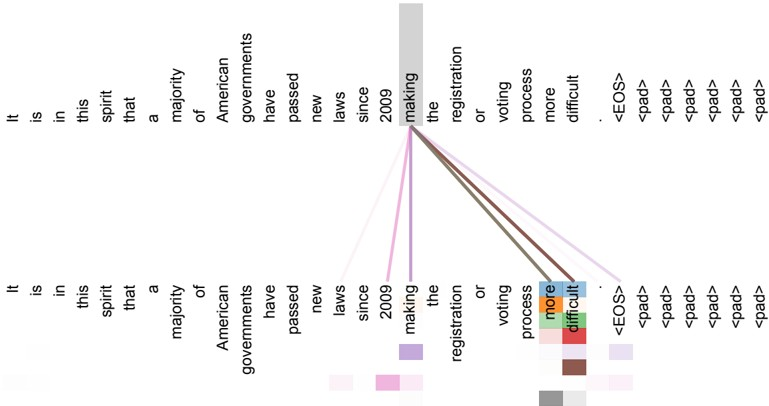


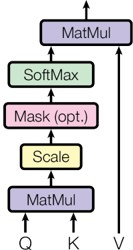


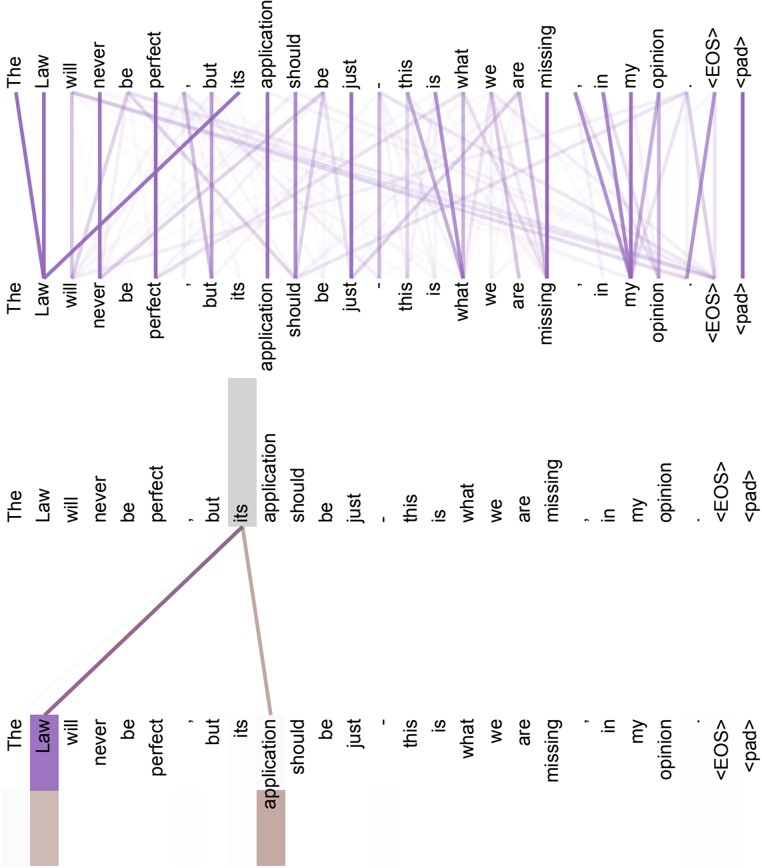


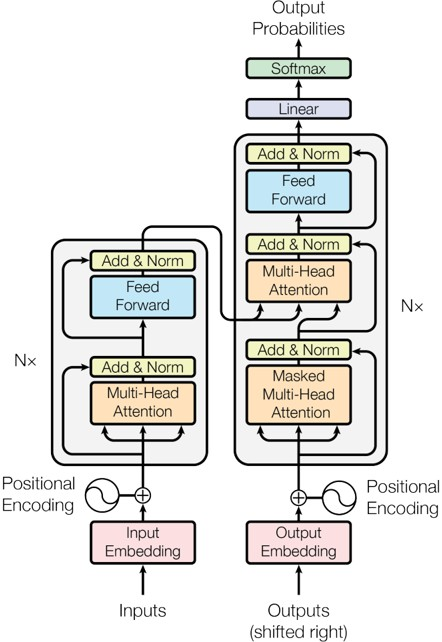

The document contains six figures and diagrams, which illustrate components and visualizations related to attention mechanisms in neural networks.

### Figure 1: Attention Visualization for "making"
This figure is an attention visualization showing how the word "making" in a sentence attends to other words.
*   **Content:** Two identical sentences are displayed vertically: "It is in this spirit that a majority of American governments have passed new laws since 2009 making the registration or voting process more difficult . <EOS> <pad> <pad> <pad> <pad> <pad> <pad> <pad>".
*   **Visual Elements:** The word "making" in the top sentence is highlighted with a grey bar. Lines connect "making" from the top sentence to several words in the bottom sentence, including "making", "the", "registration", "or", "voting", "process", "more", and "difficult". These lines vary in color (purple, red, brown) and intensity, indicating different attention weights or heads. The words "making", "more", and "difficult" in the bottom sentence are highlighted in purple, red, and brown, respectively.
*   **Insights:** This visualization demonstrates how an attention mechanism focuses on specific words when processing a particular word ("making"). It shows that "making" attends strongly to itself and also to words like "more" and "difficult," which are semantically related to the difficulty of the process being "made." The different colors suggest the presence of multiple attention heads, each potentially capturing different relationships.

### Figure 2: Scaled Dot-Product Attention
This diagram illustrates the architecture of a Scaled Dot-Product Attention mechanism.
*   **Content:** A flowchart of computational steps.
*   **Visual Elements:**
    *   Inputs are labeled Q (Query), K (Key), and V (Value).
    *   Q and K are fed into a "MatMul" (Matrix Multiplication) block.
    *   The output of this "MatMul" block goes through a "Scale" operation.
    *   Next, an optional "Mask (opt.)" is applied.
    *   The result then passes through a "SoftMax" activation function.
    *   Finally, the output of "SoftMax" is multiplied with V in another "MatMul" block to produce the final output.
*   **Insights:** This figure provides a detailed view of the core attention mechanism, showing the sequence of operations: computing similarity between queries and keys (MatMul), scaling, masking (for preventing attention to future tokens in decoding), normalizing scores (SoftMax), and then weighting values based on these scores (MatMul with V).

### Figure 3: Attention Visualization for "Law"
This figure is another attention visualization, similar to Figure 1, but focusing on the word "Law".
*   **Content:** Two identical sentences are displayed vertically: "The Law will never be perfect but its application should be just this is what we are missing in my opinion <EOS> <pad> <pad>".
*   **Visual Elements:** The word "Law" in the top sentence is highlighted with a grey bar. Lines connect "Law" from the top sentence to various words in the bottom sentence, including "The", "Law", "will", "never", "be", "perfect", "but", "its", "application", "should", "be", "just", "this", "is", "what", "we", "are", "missing", "in", "my", "opinion", and "<EOS>". The lines vary in color (purple, brown) and intensity. The words "Law" and "application" in the bottom sentence are highlighted in purple and brown, respectively.
*   **Insights:** This visualization shows that the word "Law" attends strongly to itself and also to "application," highlighting a direct relationship between the "Law" and its "application" within the sentence's context. This again suggests different attention heads focusing on different aspects of the word's relationships.

### Figure 4: Transformer Model Architecture
This diagram presents the overall architecture of a Transformer model.
*   **Content:** A block diagram showing an Encoder on the left and a Decoder on the right.
*   **Visual Elements:**
    *   **Inputs:** "Inputs" are processed by "Input Embedding" and combined with "Positional Encoding".
    *   **Encoder (left):** Consists of "Nx" identical layers. Each layer contains a "Multi-Head Attention" block followed by "Add & Norm", and then a "Feed Forward" network followed by another "Add & Norm". Skip connections are shown around both the attention and feed-forward sub-layers.
    *   **Decoder (right):** Takes "Outputs (shifted right)" which are processed by "Output Embedding" and combined with "Positional Encoding". It also consists of "Nx" identical layers. Each layer includes a "Masked Multi-Head Attention" block followed by "Add & Norm", then a "Multi-Head Attention" block (which also receives input from the Encoder's output) followed by "Add & Norm", and finally a "Feed Forward" network followed by "Add & Norm". Skip connections are present.
    *   **Output:** The Decoder's final output goes through a "Linear" layer and a "Softmax" layer to produce "Output Probabilities".
*   **Insights:** This figure provides a comprehensive overview of the Transformer architecture, a widely used model for sequence-to-sequence tasks. It clearly delineates the Encoder-Decoder structure, the role of positional encoding, and the repeated stacking ("Nx") of attention and feed-forward layers, along with residual connections and layer normalization ("Add & Norm"). The distinction between "Multi-Head Attention" in the Encoder and the two types of attention in the Decoder (masked and cross-attention) is also evident.

### Figure 5: Multi-Head Attention
This diagram details the internal structure of a Multi-Head Attention mechanism.
*   **Content:** A flowchart showing how multiple attention "heads" are combined.
*   **Visual Elements:**
    *   Inputs are Q (Query), K (Key), and V (Value).
    *   Each input (Q, K, V) is first passed through its own "Linear" transformation.
    *   The outputs of these linear transformations are then fed into multiple parallel "Scaled Dot-Product Attention" blocks (indicated by the stacked appearance and labeled 'h' for heads).
    *   The outputs from these 'h' attention heads are then combined using a "Concat" (Concatenation) operation.
    *   Finally, the concatenated output passes through another "Linear" transformation to produce the overall "Multi-Head Attention" output.
*   **Insights:** This figure explains how Multi-Head Attention works by performing several Scaled Dot-Product Attention operations in parallel, each on different linear projections of the queries, keys, and values. The results from these "heads" are then concatenated and linearly transformed, allowing the model to jointly attend to information from different representation subspaces at different positions.

### Figure 6: Multiple Attention Heads for "The"
This figure presents two different attention visualizations for the same word, demonstrating the concept of multiple attention heads.
*   **Content:** Two separate attention visualizations, one above the other, each showing the word "The" attending to other words in the sentence: "The Law will never be perfect but its application should be just this is what we are missing in my opinion <EOS> <pad> <pad>".
*   **Visual Elements:**
    *   **Top Visualization:** The word "The" in the top sentence is highlighted with a grey bar. Lines connect "The" to various words in the bottom sentence, with varying intensities, all in shades of green.
    *   **Bottom Visualization:** Similarly, the word "The" in the top sentence is highlighted with a grey bar. Lines connect "The" to various words in the bottom sentence, with varying intensities, all in shades of red.
*   **Insights:** This figure visually illustrates the benefit of "Multi-Head Attention." It shows that different attention heads (represented by green and red lines) can learn to focus on different aspects or relationships within the sentence, even for the same query word ("The"). For example, one head might emphasize grammatical connections, while another might focus on semantic relationships, providing a richer representation than a single attention mechanism.

In [23]:
# ── Example question 3: Figures / images ────────────────────────────────────
result3 = query_paper(
    "Describe the figures and diagrams in this document. "
    "What do they show and what insights do they provide?"
)

In [24]:
# ── Example question 4: Methods ──────────────────────────────────────────────
result4 = query_paper("What methodology or approach does the paper propose?")


QUESTION: What methodology or approach does the paper propose?

Retrieved: 6 text  |  0 table  |  0 image



The provided context describes aspects of the training regime for the models, stating:

*   "This section describes the training regime for our models" (page 7).
*   "We employ three types of regularization during training" (page 7).

However, the context does not explicitly state what the overall methodology or approach proposed by the paper is. It only details specific components of the training process. Therefore, the context is insufficient to fully answer what methodology or approach the paper proposes.

In [25]:
# ── YOUR QUESTION — edit and run this cell ───────────────────────────────────
your_question = "What are the conclusions and future work directions?"

result_custom = query_paper(your_question)


QUESTION: What are the conclusions and future work directions?

Retrieved: 6 text  |  0 table  |  0 image



Based on the provided context, there is no information regarding the conclusions and future work directions. The available text describes aspects of the training regime, such as model averaging and inference hyperparameters (page 8), and author information (page 1).

In [26]:
# ── YOUR QUESTION — edit and run this cell ───────────────────────────────────
your_question = "What is attention?"

result_custom = query_paper(your_question)


QUESTION: What is attention?

Retrieved: 6 text  |  0 table  |  0 image



Attention can be described as:

*   **Function Mapping**
    An attention function maps a query and a set of key-value pairs to an output. The query, keys, values, and output are all vectors (page 3). The output is calculated as a weighted sum (page 3).

*   **Types of Attention**
    The two most commonly used attention functions are additive attention and dot-product (multiplicative) attention (page 4).
    *   **Dot-product attention** is identical to the described algorithm, except for a scaling factor of 1/√d_k (page 4). It is much faster and more space-efficient in practice than additive attention, as it can be implemented using highly optimized matrix multiplication code (page 4).
    *   **Additive attention** computes the compatibility function using a feed-forward network with a single hidden layer (page 4).
    *   **Scaled Dot-Product Attention** is depicted in Figure 2 (left) (page 4).
    *   **Multi-Head Attention** consists of several attention layers running in parallel, as shown in Figure 2 (right) (page 4).

*   **Self-attention**
    Self-attention, also known as intra-attention, is an attention mechanism that relates different positions of a single sequence to compute a representation of that sequence (page 2). It has been successfully used in tasks such as reading comprehension, abstractive summarization, textual entailment, and learning task-independent sentence representations (page 2). Ankur Parikh et al. (2016) developed a decomposable attention model (page 12).

## Step 11 — Interactive Q&A Widget
A live input box — type any question and click **Ask**. No need to edit code cells.

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Interactive Q&A Widget ───────────────────────────────────────────────────
question_input = widgets.Textarea(
    value="What is the main contribution of this paper?",
    placeholder="Type your question here…",
    description="",
    layout=widgets.Layout(width="80%", height="80px"),
)
k_slider = widgets.IntSlider(
    value=6, min=2, max=12, step=1,
    description="k (docs):",
    continuous_update=False,
    style={"description_width": "80px"},
)
show_src_toggle = widgets.ToggleButton(
    value=True, description="Show Sources",
    button_style="info", icon="search",
    layout=widgets.Layout(width="150px"),
)
run_btn = widgets.Button(
    description="Ask ▶", button_style="success",
    layout=widgets.Layout(width="100px"),
)
out = widgets.Output()

def on_run_clicked(_):
    with out:
        clear_output(wait=True)
        q = question_input.value.strip()
        if not q:
            print("Please enter a question.")
            return
        try:
            query_paper(
                q,
                k=k_slider.value,
                show_sources=show_src_toggle.value,
            )
        except Exception as exc:
            print(f"Error: {exc}")

run_btn.on_click(on_run_clicked)

header = widgets.HTML("<h3>🔍 Interactive Multimodal Q&A</h3>")
controls = widgets.HBox([
    widgets.VBox([question_input]),
    widgets.VBox([k_slider, show_src_toggle, run_btn],
                 layout=widgets.Layout(margin="0 0 0 16px")),
])
display(widgets.VBox([header, controls, out]))

## Step 12 — Document Statistics Dashboard
Summary of what was extracted and indexed from the document.

In [28]:
from IPython.display import display, HTML

stats_html = f"""
<div style="font-family:sans-serif;padding:16px;background:#f0f4ff;
            border-radius:8px;border:1px solid #c0c8e8;max-width:620px">
  <h2 style="margin:0 0 12px 0;color:#2d3a8c">📊 RAG System Statistics</h2>
  <table style="border-collapse:collapse;width:100%">
    <thead>
      <tr style="background:#2d3a8c;color:#fff">
        <th style="padding:8px 12px;text-align:left">Component</th>
        <th style="padding:8px 12px;text-align:left">Detail</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">PDF Parser</td>
        <td style="padding:7px 12px">docling (IBM) — no OCR dependencies</td>
      </tr>
      <tr style="background:#f7f9ff">
        <td style="padding:7px 12px;font-weight:bold">Text chunks</td>
        <td style="padding:7px 12px">{len(texts)}</td>
      </tr>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">Tables</td>
        <td style="padding:7px 12px">{len(tables)}</td>
      </tr>
      <tr style="background:#f7f9ff">
        <td style="padding:7px 12px;font-weight:bold">Images / Charts</td>
        <td style="padding:7px 12px">{len(images)}</td>
      </tr>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">Text summariser</td>
        <td style="padding:7px 12px">llama-3.3-70b-versatile (Groq)</td>
      </tr>
      <tr style="background:#f7f9ff">
        <td style="padding:7px 12px;font-weight:bold">Image summariser</td>
        <td style="padding:7px 12px">gemini-2.5-flash (Google)</td>
      </tr>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">Embedding model</td>
        <td style="padding:7px 12px">BAAI/bge-base-en-v1.5 (768-dim)</td>
      </tr>
      <tr style="background:#f7f9ff">
        <td style="padding:7px 12px;font-weight:bold">Vector store</td>
        <td style="padding:7px 12px">ChromaDB 1.5.x (persistent)</td>
      </tr>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">Retriever</td>
        <td style="padding:7px 12px">MultiVectorRetriever (langchain-classic)</td>
      </tr>
      <tr style="background:#f7f9ff">
        <td style="padding:7px 12px;font-weight:bold">Answer model</td>
        <td style="padding:7px 12px">gemini-2.5-flash (multimodal)</td>
      </tr>
      <tr style="background:#fff">
        <td style="padding:7px 12px;font-weight:bold">Total vectors</td>
        <td style="padding:7px 12px">{vectorstore._collection.count()}</td>
      </tr>
    </tbody>
  </table>
</div>
"""
display(HTML(stats_html))

Component,Detail
PDF Parser,docling (IBM) — no OCR dependencies
Text chunks,137
Tables,4
Images / Charts,6
Text summariser,llama-3.3-70b-versatile (Groq)
Image summariser,gemini-2.5-flash (Google)
Embedding model,BAAI/bge-base-en-v1.5 (768-dim)
Vector store,ChromaDB 1.5.x (persistent)
Retriever,MultiVectorRetriever (langchain-classic)
Answer model,gemini-2.5-flash (multimodal)


## Step 13 — Persist & Reload ChromaDB
On subsequent runs you can **skip Steps 4-8** and reload the existing index directly.
This saves time for large documents that have already been processed.

In [29]:
# ── Persist: ChromaDB auto-persists with persist_directory ──────────────────
# Nothing extra needed for chromadb >= 0.4. Data is on disk at CHROMA_DIR.
print(f"ChromaDB persisted at: {CHROMA_DIR}")
print(f"Vectors in collection: {vectorstore._collection.count()}")
print()
print("To reload on a future run without re-processing the PDF:")
print("""
  import warnings; warnings.filterwarnings('ignore', category=DeprecationWarning)
  from langchain_chroma import Chroma
  from langchain_classic.storage import InMemoryStore
  from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

  vectorstore = Chroma(
      collection_name='multimodal_rag',
      embedding_function=embedding_model,   # must re-init embeddings first
      persist_directory='./chroma_db',
  )
  docstore  = InMemoryStore()
  retriever = MultiVectorRetriever(
      vectorstore=vectorstore,
      docstore=docstore,
      id_key='doc_id',
      search_kwargs={'k': 6},
  )
  # Then call query_paper('your question')
""")

ChromaDB persisted at: ./chroma_db
Vectors in collection: 147

To reload on a future run without re-processing the PDF:

  import warnings; warnings.filterwarnings('ignore', category=DeprecationWarning)
  from langchain_chroma import Chroma
  from langchain_classic.storage import InMemoryStore
  from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

  vectorstore = Chroma(
      collection_name='multimodal_rag',
      embedding_function=embedding_model,   # must re-init embeddings first
      persist_directory='./chroma_db',
  )
  docstore  = InMemoryStore()
  retriever = MultiVectorRetriever(
      vectorstore=vectorstore,
      docstore=docstore,
      id_key='doc_id',
      search_kwargs={'k': 6},
  )
  # Then call query_paper('your question')



## Step 14 — Advanced: PyMuPDF Deep Metadata Extraction (Supplemental)
`PyMuPDF (fitz)` provides low-level access to PDF metadata, fonts, page dimensions, hyperlinks, annotations, and embedded objects. Use this for any metadata-level questions.

In [30]:
import fitz   # PyMuPDF

def extract_pdf_metadata(pdf_path: str) -> dict:
    """
    Extract document-level metadata, TOC, annotations, and links using PyMuPDF.
    """
    doc = fitz.open(pdf_path)

    meta = doc.metadata
    toc  = doc.get_toc()       # [[level, title, page], ...]

    page_info = []
    annotations = []
    links_all   = []

    for page_num, page in enumerate(doc):
        info = {
            "page"  : page_num + 1,
            "width" : round(page.rect.width,  1),
            "height": round(page.rect.height, 1),
            "blocks": len(page.get_text("blocks")),
        }
        page_info.append(info)

        for annot in page.annots():
            annotations.append({
                "page": page_num + 1,
                "type": annot.type[1],
                "content": annot.info.get("content", ""),
            })

        for link in page.get_links():
            if link.get("uri"):
                links_all.append({"page": page_num + 1, "url": link["uri"]})

    doc.close()
    return {
        "metadata"   : meta,
        "num_pages"  : len(page_info),
        "toc"        : toc,
        "pages"      : page_info,
        "annotations": annotations,
        "links"      : links_all,
    }


if Path(PDF_PATH).exists():
    pdf_meta = extract_pdf_metadata(PDF_PATH)

    print("── PDF Metadata ────────────────────────────────────────────────────")
    for k, v in pdf_meta["metadata"].items():
        if v:
            print(f"  {k:<14}: {v}")

    print(f"\n── Pages: {pdf_meta['num_pages']}")
    if pdf_meta["toc"]:
        print(f"\n── Table of Contents ({len(pdf_meta['toc'])} entries):")
        for level, title, page in pdf_meta["toc"][:20]:
            print(f"  {'  ' * (level-1)}{title}  (p.{page})")
    if pdf_meta["links"]:
        print(f"\n── External Links ({len(pdf_meta['links'])}):")
        for lnk in pdf_meta["links"][:10]:
            print(f"  p.{lnk['page']}: {lnk['url']}")
else:
    print("PDF_PATH not found — set it in Step 3 first.")

── PDF Metadata ────────────────────────────────────────────────────
  format        : PDF 1.5
  creator       : LaTeX with hyperref
  producer      : pdfTeX-1.40.25
  creationDate  : D:20240410211143Z
  modDate       : D:20240410211143Z

── Pages: 15

── Table of Contents (22 entries):
  Introduction  (p.2)
  Background  (p.2)
  Model Architecture  (p.2)
    Encoder and Decoder Stacks  (p.3)
    Attention  (p.3)
      Scaled Dot-Product Attention  (p.4)
      Multi-Head Attention  (p.4)
      Applications of Attention in our Model  (p.5)
    Position-wise Feed-Forward Networks  (p.5)
    Embeddings and Softmax  (p.5)
    Positional Encoding  (p.6)
  Why Self-Attention  (p.6)
  Training  (p.7)
    Training Data and Batching  (p.7)
    Hardware and Schedule  (p.7)
    Optimizer  (p.7)
    Regularization  (p.7)
  Results  (p.8)
    Machine Translation  (p.8)
    Model Variations  (p.8)

── External Links (18):
  p.10: https://github.com/tensorflow/tensor2tensor
  p.10: https://github.com

## Step 15 — Advanced: pdfplumber Precision Table Extraction (Supplemental)
`pdfplumber` uses heuristic line detection for tables. Useful as a **second pass** when Unstructured misses or garbles a table.

In [32]:
import pdfplumber, pandas as pd

# ── pdfplumber supplemental table extraction ─────────────────────────────────
# Useful for PDFs where docling's table detection misses borderless grids.

extra_tables = []   # list of table dicts matching docling format

for pdf_path in pdf_files:
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for pg_no, page in enumerate(pdf.pages, start=1):
                for raw_tbl in page.extract_tables():
                    if not raw_tbl or len(raw_tbl) < 2:
                        continue
                    df = pd.DataFrame(raw_tbl[1:], columns=raw_tbl[0])
                    html = df.to_html(index=False, border=1,
                                      classes="pdfplumber-table")
                    extra_tables.append({
                        "html":     html,
                        "df":       df,
                        "markdown": df.to_markdown(index=False),
                        "page":     pg_no,
                        "caption":  f"pdfplumber table (p.{pg_no})",
                        "label":    "table",
                        "source":   "pdfplumber",
                    })
    except Exception as exc:
        print(f"  ⚠ pdfplumber error on {pdf_path.name}: {exc}")

print(f"pdfplumber found {len(extra_tables)} supplemental table(s)")
if extra_tables:
    print("Sample:")
    display(extra_tables[0]["df"].head(3))

NameError: name 'pdf_files' is not defined

## Step 16 — Advanced: Add pdfplumber Tables to the Index
If pdfplumber found additional / better tables, summarise and index them too.

In [ ]:
# ── Index supplemental pdfplumber tables ─────────────────────────────────────
if extra_tables:
    print(f"Summarising {len(extra_tables)} extra table(s) …")
    extra_summaries = []
    for tbl in extra_tables:
        try:
            s = table_chain.invoke(tbl)
        except Exception:
            s = tbl.get("markdown", "")[:300]
        extra_summaries.append(s)

    extra_ids = _add_to_retriever(
        extra_tables, extra_summaries, retriever, modality="table",
        extra_meta_fn=lambda i, el: {
            "page":   el.get("page", -1),
            "caption": el.get("caption", ""),
            "source": "pdfplumber",
        },
    )
    # Extend master list so stats reflect them
    tables.extend(extra_tables)
    table_summaries.extend(extra_summaries)
    table_ids.extend(extra_ids)

    print(f"  Indexed {len(extra_ids)} extra table(s) ✓")
    print(f"  Total tables now: {len(tables)}")
else:
    print("No extra tables to index.")

## Step 17 — Batch Q&A: Run Many Questions at Once
Useful for generating a complete report / knowledge base of answers from a paper.

In [ ]:
import json, time

BATCH_QUESTIONS = [
    "Who are the authors and what institution are they from?",
    "What problem does this paper solve?",
    "What is the proposed methodology or model?",
    "What datasets were used for evaluation?",
    "What are the main experimental results? Include numbers from tables.",
    "How does this work compare to prior / related work?",
    "What are the key figures and what do they show?",
    "What are the limitations of the proposed approach?",
    "What future work do the authors suggest?",
    "Summarize the paper in 5 bullet points.",
]

def run_batch_qa(questions: list, save_json: bool = True) -> list:
    """
    Run all questions and collect answers.
    Optionally saves results to batch_qa_results.json.
    """
    results = []
    for i, q in enumerate(questions):
        print(f"[{i+1}/{len(questions)}] {q}")
        try:
            raw_docs = retriever.invoke(q)
            ctx      = classify_docs(raw_docs)
            msgs     = build_rag_prompt(ctx, q)
            ans      = gemini_answer.invoke(msgs).content
        except Exception as exc:
            ans = f"[Error: {exc}]"

        results.append({"question": q, "answer": ans})
        print(f"         → {ans[:120]} …\n")
        time.sleep(0.5)   # rate-limit courtesy

    if save_json:
        out_path = "./batch_qa_results.json"
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2, ensure_ascii=False)
        print(f"\nResults saved to {out_path}")

    return results


# Uncomment to run all batch questions (takes ~1-2 min):
# batch_results = run_batch_qa(BATCH_QUESTIONS)

print("run_batch_qa() defined. Uncomment the last line to execute.")

## Step 18 — Export Full Paper Report to HTML
Generate a self-contained HTML file with all answers, tables, and images — shareable without Jupyter.

In [ ]:
from pathlib import Path
import html as html_module

def build_html_report(output_path: str = "content/report.html") -> None:
    """
    Generate a self-contained HTML report of all extracted elements.
    Images are embedded as data-URIs; tables are rendered inline.
    """
    sections = []

    # ── Text chunks ──────────────────────────────────────────────────────────
    sections.append("<h2>📄 Text Chunks</h2>")
    for i, t in enumerate(texts):
        if isinstance(t, dict):
            page  = t.get("page", "?")
            label = t.get("label", "text").upper()
            text  = html_module.escape(t.get("text", ""))
        else:
            page  = getattr(getattr(t, "metadata", None), "page_number", "?")
            label = "TEXT"
            text  = html_module.escape(str(t))
        sections.append(
            f'<div class="chunk">'
            f'<span class="badge">{label}</span>&nbsp; page&nbsp;{page}'
            f'<pre>{text[:600]}</pre></div>'
        )

    # ── Tables ───────────────────────────────────────────────────────────────
    sections.append("<h2>📋 Tables</h2>")
    for i, tbl in enumerate(tables):
        if isinstance(tbl, dict):
            page    = tbl.get("page", "?")
            caption = html_module.escape(tbl.get("caption", ""))
            html_content = tbl.get("html", "<em>no HTML</em>")
        else:
            page = caption = "?"
            html_content = "<em>no HTML</em>"
        sections.append(
            f'<div class="chunk">'
            f'<span class="badge">TABLE</span>&nbsp; page&nbsp;{page}'
            f'{"<br><em>"+caption+"</em>" if caption else ""}'
            f'{html_content}</div>'
        )

    # ── Images ───────────────────────────────────────────────────────────────
    sections.append("<h2>🖼 Figures / Charts</h2>")
    for i, img in enumerate(images):
        if isinstance(img, dict):
            b64     = img.get("b64", "")
            page    = img.get("page", "?")
            label   = img.get("label", "picture").upper()
            caption = html_module.escape(img.get("caption", ""))
        else:
            b64 = img if isinstance(img, str) else ""
            page = label = "?"; caption = "PICTURE"
        if not b64:
            continue
        sections.append(
            f'<div class="chunk">'
            f'<span class="badge">{label}</span>&nbsp; page&nbsp;{page}'
            f'{"<br><em>"+caption+"</em>" if caption else ""}<br>'
            f'<img src="data:image/jpeg;base64,{b64}" '
            f'style="max-width:600px;max-height:400px;margin-top:8px"></div>'
        )

    body = "\n".join(sections)
    full_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Multimodal RAG Extraction Report</title>
<style>
  body {{font-family:sans-serif;margin:24px;background:#f9faff}}
  h2 {{color:#2d3a8c;margin-top:32px}}
  .chunk {{border:1px solid #dde;border-radius:6px;padding:12px;margin:8px 0;background:#fff}}
  .badge {{background:#2d3a8c;color:#fff;padding:2px 8px;border-radius:12px;font-size:0.8em;font-weight:bold}}
  pre {{white-space:pre-wrap;font-size:0.85em;background:#f4f5ff;padding:8px;border-radius:4px;overflow:auto}}
  table {{border-collapse:collapse;width:100%;margin-top:8px}}
  th,td {{border:1px solid #ccc;padding:5px 8px;font-size:0.85em}}
  th {{background:#eef0ff}}
</style>
</head>
<body>
<h1>Multimodal RAG Extraction Report</h1>
<p>Extracted with <b>docling</b> · {len(texts)} text chunks · {len(tables)} tables · {len(images)} images</p>
{body}
</body></html>"""

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    Path(output_path).write_text(full_html, encoding="utf-8")
    print(f"Report saved to: {output_path}")


build_html_report()
display(HTML('<a href="content/report.html" target="_blank">Open HTML Report ↗</a>'))

In [ ]:
from IPython.display import display, HTML

refs = [
    ("docling (IBM, 2024)",           "https://github.com/DS4SD/docling",
     "PDF/Office parser — text, tables, charts, figures with layout understanding"),
    ("LangChain 1.x",                 "https://python.langchain.com/",
     "Orchestration framework for LLM applications"),
    ("langchain-classic 1.0.x",       "https://github.com/langchain-ai/langchain",
     "Multi-vector retriever + InMemoryStore for langchain 1.x"),
    ("ChromaDB 1.5.x",                "https://www.trychroma.com/",
     "Persistent vector database via langchain-chroma"),
    ("BAAI/bge-base-en-v1.5",         "https://huggingface.co/BAAI/bge-base-en-v1.5",
     "768-dim embedding model, strong semantic similarity for retrieval"),
    ("Groq / llama-3.3-70b-versatile","https://console.groq.com/docs/models",
     "Fast text & table summarisation — 280 tok/s, 131k context"),
    ("Google Gemini 2.5 Flash",        "https://ai.google.dev/gemini-api/docs/models",
     "Multimodal final-answer model — vision + 1M context window"),
    ("sentence-transformers 5.x",     "https://www.sbert.net/",
     "HuggingFace sentence embeddings library"),
    ("ipywidgets",                    "https://ipywidgets.readthedocs.io/",
     "Interactive notebook UI widgets"),
]

rows = "".join(
    f'<tr><td><a href="{url}" target="_blank">{name}</a></td>'
    f'<td>{desc}</td></tr>'
    for name, url, desc in refs
)
display(HTML(f"""
<h3>📚 Component References</h3>
<table style="border-collapse:collapse;font-family:sans-serif;width:100%">
  <thead>
    <tr style="background:#2d3a8c;color:#fff">
      <th style="padding:8px 12px;text-align:left">Component</th>
      <th style="padding:8px 12px;text-align:left">Description</th>
    </tr>
  </thead>
  <tbody>{rows}</tbody>
</table>
"""))